## Global Healthcare Budget Optimization Modeling

Team: Anvith Mulpuri, Ansh Pathapati, Sahana Subramanyam, Akhila Arhla, Raahim Jawad

Dataset: https://apps.who.int/nha/database/Select/Indicators/en

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
print('All imports successful.')

df = pd.read_csv("modeling.csv")

All imports successful.


In [47]:
df

,location,code,region,income,year,Health Expenditure % of GDP,Health Expenditure Per Capita (USD),Govt Share of Health Expenditure (%),Private Share of Health Expenditure (%),Out-of-Pocket Share of Health Expenditure (%),Voluntary Health Insurance Share of Health Expenditure (%),External Aid Share of Health Expenditure (%),Social Health Insurance Share of Health Expenditure (%),Social Health Insurance Funds Per Capita (Local Currency),Voluntary Health Insurance Per Capita (Local Currency),Voluntary Health Insurance Per Capita (Local Currency).1,Ministry of Health Per Capita (Local Currency),GDP Per Capita (USD),General Govt Expenditure % of GDP,Govt Health Expenditure % of GDP,Total Population
0,Antigua and Barbuda,ATG,AMR,High,2000,4.3,520,57.8,41.8,22.2,19.6,0.3,21.7,275,5,312,512,"12,029",21.1,2.5,75
1,Antigua and Barbuda,ATG,AMR,High,2001,5.0,572,59.1,40.8,22.7,18.1,0.1,20.9,280,1,351,591,"11,539",24.2,2.9,76
2,Antigua and Barbuda,ATG,AMR,High,2002,4.8,559,58.4,41.4,22.7,18.7,0.1,17.1,282,2,343,626,"11,659",26.3,2.8,77
3,Antigua and Barbuda,ATG,AMR,High,2003,5.0,614,59.9,40.1,23.2,16.9,0.0,16.5,280,0,385,720,"12,174",24.3,3.0,78
4,Antigua and Barbuda,ATG,AMR,High,2004,4.6,598,58.0,41.9,24.3,17.6,0.0,16.9,285,0,392,664,"13,037",21.9,2.7,79
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4607,Viet Nam,VNM,WPR,Lower-middle,2019,5.0,171,40.6,58.4,45.1,4.5,1.0,32.3,"560,540","2,140","1,779,931","329,479","3,441",19.8,2.0,"97,174"
4608,Viet Nam,VNM,WPR,Lower-middle,2020,4.3,153,41.3,57.0,42.4,4.4,1.7,30.6,"551,969","25,902","1,506,692","406,954","3,534",21.3,1.8,"98,079"
4609,Viet Nam,VNM,WPR,Lower-middle,2021,4.5,168,43.2,55.6,40.5,4.9,1.2,23.7,"604,065","31,981","1,575,258","792,720","3,704",20.1,2.0,"98,935"
4610,Viet Nam,VNM,WPR,Lower-middle,2022,4.5,188,43.4,55.0,39.6,5.5,1.6,25.8,"701,740","40,707","1,735,741","814,632","4,148",18.2,2.0,"99,681"


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4612 entries, 0 to 4611
Data columns (total 21 columns):
 #   Column                                                      Non-Null Count  Dtype  
---  ------                                                      --------------  -----  
 0   location                                                    4612 non-null   object 
 1   code                                                        4612 non-null   object 
 2   region                                                      4612 non-null   object 
 3   income                                                      4612 non-null   object 
 4   year                                                        4612 non-null   int64  
 5   Health Expenditure % of GDP                                 4610 non-null   float64
 6   Health Expenditure Per Capita (USD)                         4607 non-null   object 
 7   Govt Share of Health Expenditure (%)                        4595 non-null   float64
 8 

In [49]:
df.describe()

,year,Health Expenditure % of GDP,Govt Share of Health Expenditure (%),Private Share of Health Expenditure (%),Out-of-Pocket Share of Health Expenditure (%),Voluntary Health Insurance Share of Health Expenditure (%),External Aid Share of Health Expenditure (%),Social Health Insurance Share of Health Expenditure (%),General Govt Expenditure % of GDP,Govt Health Expenditure % of GDP
count,4612.000000,4610.000000,4595.000000,4595.000000,4610.00000,4185.000000,4030.000000,4434.000000,4610.000000,4595.000000
mean,2011.664354,6.289783,50.937454,40.077650,33.09692,4.898447,10.242705,14.977289,32.069675,3.349162
std,6.955795,3.158302,22.316763,19.644561,19.72015,6.806752,15.365441,22.578111,16.558453,2.547587
min,2000.000000,1.200000,0.800000,0.100000,0.00000,0.000000,0.000000,0.000000,1.900000,0.100000
25%,2006.000000,4.100000,33.700000,25.500000,16.30000,0.700000,0.100000,0.000000,21.000000,1.500000
50%,2012.000000,5.700000,52.100000,38.800000,30.80000,2.600000,2.400000,1.600000,29.300000,2.700000
75%,2018.000000,8.000000,69.900000,54.900000,46.80000,6.400000,15.000000,23.600000,39.900000,4.600000
max,2024.000000,79.700000,99.900000,89.200000,87.90000,50.600000,81.600000,84.000000,186.500000,42.500000


In [50]:
# Fix columns read as strings due to comma-formatted numbers (e.g. '1,134')
for col in df.columns:
    if df[col].dtype == object:
        try:
            df[col] = df[col].str.replace(',', '', regex=False).astype(float)
        except (ValueError, AttributeError):
            pass  # leaves true string columns (location, code, region, income) as-is

In [51]:
print('Missing values before cleaning:')
print(df.isna().sum()[df.isna().sum() > 0])

Missing values before cleaning:
Health Expenditure % of GDP                                     2
Health Expenditure Per Capita (USD)                             5
Govt Share of Health Expenditure (%)                           17
Private Share of Health Expenditure (%)                        17
Out-of-Pocket Share of Health Expenditure (%)                   2
Voluntary Health Insurance Share of Health Expenditure (%)    427
External Aid Share of Health Expenditure (%)                  582
Social Health Insurance Share of Health Expenditure (%)       178
Social Health Insurance Funds Per Capita (Local Currency)      44
Voluntary Health Insurance Per Capita (Local Currency)        883
Voluntary Health Insurance Per Capita (Local Currency).1        2
Ministry of Health Per Capita (Local Currency)                  4
GDP Per Capita (USD)                                            5
General Govt Expenditure % of GDP                               2
Govt Health Expenditure % of GDP            

In [52]:
# --- Drop high-missingness columns (>10% missing) ---
# Based on EDA: External Aid Share (~582), Voluntary Health Insurance columns (~427-883)
HIGH_MISSING_COLS = [
    'External Aid Share of Health Expenditure (%)',
    'Voluntary Health Insurance Share of Health Expenditure (%)',
    'Voluntary Health Insurance Per Capita (Local Currency)',
    'Voluntary Health Insurance Per Capita (Local Currency).1',
]
# Only drop columns that actually exist in the dataframe
cols_to_drop = [c for c in HIGH_MISSING_COLS if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)
print(f'Dropped {len(cols_to_drop)} high-missingness columns: {cols_to_drop}')

Dropped 4 high-missingness columns: ['External Aid Share of Health Expenditure (%)', 'Voluntary Health Insurance Share of Health Expenditure (%)', 'Voluntary Health Insurance Per Capita (Local Currency)', 'Voluntary Health Insurance Per Capita (Local Currency).1']


In [53]:
# --- Drop rows where the TARGET is missing ---
TARGET = 'Health Expenditure % of GDP'
before = len(df)
df.dropna(subset=[TARGET], inplace=True)
print(f'Dropped {before - len(df)} rows with missing target. Remaining: {len(df)}')

Dropped 2 rows with missing target. Remaining: 4610


In [54]:
# --- Forward/backward fill within each country for panel features ---
# Sort by country code and year to ensure correct temporal order
df.sort_values(['code', 'year'], inplace=True)

PANEL_FILL_COLS = [
    'Govt Share of Health Expenditure (%)',
    'Private Share of Health Expenditure (%)',
    'Govt Health Expenditure % of GDP',
    'Social Health Insurance Share of Health Expenditure (%)',
    'Social Health Insurance Funds Per Capita (Local Currency)',
    'GDP Per Capita (USD)',
    'General Govt Expenditure % of GDP',
    'Out-of-Pocket Share of Health Expenditure (%)',
    'Health Expenditure Per Capita (USD)',
    'Ministry of Health Per Capita (Local Currency)',
]

# Only process columns that exist
panel_cols_present = [c for c in PANEL_FILL_COLS if c in df.columns]

df[panel_cols_present] = (
    df.groupby('code')[panel_cols_present]
    .transform(lambda x: x.ffill().bfill())
)

print('Missing values after panel fill:')
remaining = df.isna().sum()
print(remaining[remaining > 0])

Missing values after panel fill:
Social Health Insurance Share of Health Expenditure (%)      24
Social Health Insurance Funds Per Capita (Local Currency)    24
dtype: int64


In [55]:
# --- Final fallback: median imputation by income group for anything still missing ---
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
df[numeric_cols] = df.groupby('income')[numeric_cols].transform(
    lambda x: x.fillna(x.median())
)

print('\nMissing values after all imputation:')
print(df.isna().sum().sum(), 'total remaining')


Missing values after all imputation:
0 total remaining


In [56]:
# Define features to use for modeling
# Excluding: target, identifiers, and leaky variables
# NOTE: 'Govt Health Expenditure % of GDP' is a very strong predictor (r=0.757-0.865)
# Include it but be aware it may dominate. Remove it if you want a purer model.

FEATURES = [
    'Govt Share of Health Expenditure (%)',
    'Private Share of Health Expenditure (%)',
    'Out-of-Pocket Share of Health Expenditure (%)',
    'Social Health Insurance Share of Health Expenditure (%)',
    'GDP Per Capita (USD)',
    'General Govt Expenditure % of GDP',
    'Govt Health Expenditure % of GDP',
    'Total Population',
    'year',
]

# Only keep features that exist in the dataframe
FEATURES = [f for f in FEATURES if f in df.columns]

# Encode region and income as dummies
df_model = pd.get_dummies(df[FEATURES + [TARGET, 'region', 'income']], 
                           columns=['region', 'income'], drop_first=True)

X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

print(f'Features: {X.shape[1]}')
print(f'Samples:  {X.shape[0]}')
print(f'Target:   {TARGET}')
X.head()

Features: 17
Samples:  4610
Target:   Health Expenditure % of GDP


,Govt Share of Health Expenditure (%),Private Share of Health Expenditure (%),Out-of-Pocket Share of Health Expenditure (%),Social Health Insurance Share of Health Expenditure (%),GDP Per Capita (USD),General Govt Expenditure % of GDP,Govt Health Expenditure % of GDP,Total Population,year,region_AMR,region_EMR,region_EUR,region_SEAR,region_WPR,income_Low,income_Lower-middle,income_Upper-middle
1926,0.9,85.4,85.4,0.0,177.0,6.9,0.1,21378.0,2002,False,True,False,False,False,True,False,False
1927,7.3,86.1,86.1,0.0,198.0,11.9,0.7,22733.0,2003,False,True,False,False,False,True,False,False
1928,5.5,84.5,84.5,0.0,218.0,15.1,0.5,23561.0,2004,False,True,False,False,False,True,False,False
1929,5.3,79.0,79.0,0.0,252.0,15.7,0.5,24405.0,2005,False,True,False,False,False,True,False,False
1930,4.7,76.8,76.8,0.0,272.0,18.3,0.5,25424.0,2006,False,True,False,False,False,True,False,False


In [57]:
# Temporal split: train on earlier years, test on most recent years
# This is more realistic than random split for panel data
SPLIT_YEAR = 2019  # ~80/20 split given 2000-2023 range

train_mask = df['year'] <= SPLIT_YEAR
X_train = X[train_mask.values]
X_test  = X[~train_mask.values]
y_train = y[train_mask.values]
y_test  = y[~train_mask.values]

print(f'Train: {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test:  {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.1f}%)')

Train: 3810 rows (82.6%)
Test:  800 rows (17.4%)


In [58]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Fit model, evaluate on test set, return metrics dict."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)
    r2   = r2_score(y_te, y_pred)
    
    # 5-fold CV on training set
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2')
    
    print(f'\n── {name} ──')
    print(f'  Test R²:    {r2:.4f}')
    print(f'  Test RMSE:  {rmse:.4f}')
    print(f'  Test MAE:   {mae:.4f}')
    print(f'  CV R² (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    
    return {'Model': name, 'R²': round(r2,4), 'RMSE': round(rmse,4), 
            'MAE': round(mae,4), 'CV R² Mean': round(cv_scores.mean(),4),
            'CV R² Std': round(cv_scores.std(),4)}

In [59]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

results = []

# --- 1. Linear Regression (baseline) ---
lr = LinearRegression()
results.append(evaluate_model('Linear Regression', lr, X_train_sc, y_train, X_test_sc, y_test))

# --- 2. Ridge Regression (CV to find best alpha) ---
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
results.append(evaluate_model('Ridge Regression', ridge, X_train_sc, y_train, X_test_sc, y_test))
print(f'  Best alpha: {ridge.alpha_:.4f}')

# --- 3. Lasso Regression (CV to find best alpha) ---
lasso = LassoCV(alphas=np.logspace(-4, 1, 50), cv=5, max_iter=10000)
results.append(evaluate_model('Lasso Regression', lasso, X_train_sc, y_train, X_test_sc, y_test))
print(f'  Best alpha: {lasso.alpha_:.4f}')

# --- 4. Random Forest (no scaling needed) ---
rf = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=5,
                            random_state=42, n_jobs=-1)
results.append(evaluate_model('Random Forest', rf, X_train, y_train, X_test, y_test))


── Linear Regression ──
  Test R²:    0.8020
  Test RMSE:  1.4475
  Test MAE:   0.8010
  CV R² (5-fold): 0.8483 ± 0.0451

── Ridge Regression ──
  Test R²:    0.8022
  Test RMSE:  1.4468
  Test MAE:   0.7999
  CV R² (5-fold): 0.8488 ± 0.0443
  Best alpha: 4.7149

── Lasso Regression ──
  Test R²:    0.8021
  Test RMSE:  1.4474
  Test MAE:   0.7948
  CV R² (5-fold): 0.8489 ± 0.0447
  Best alpha: 0.0110

── Random Forest ──
  Test R²:    0.8835
  Test RMSE:  1.1104
  Test MAE:   0.3808
  CV R² (5-fold): 0.8183 ± 0.0911


In [60]:
results_df = pd.DataFrame(results).sort_values('R²', ascending=False)
print('\n=== Model Comparison ===')
print(results_df.to_string(index=False))


=== Model Comparison ===
            Model     R²   RMSE    MAE  CV R² Mean  CV R² Std
    Random Forest 0.8835 1.1104 0.3808      0.8183     0.0911
 Ridge Regression 0.8022 1.4468 0.7999      0.8488     0.0443
 Lasso Regression 0.8021 1.4474 0.7948      0.8489     0.0447
Linear Regression 0.8020 1.4475 0.8010      0.8483     0.0451


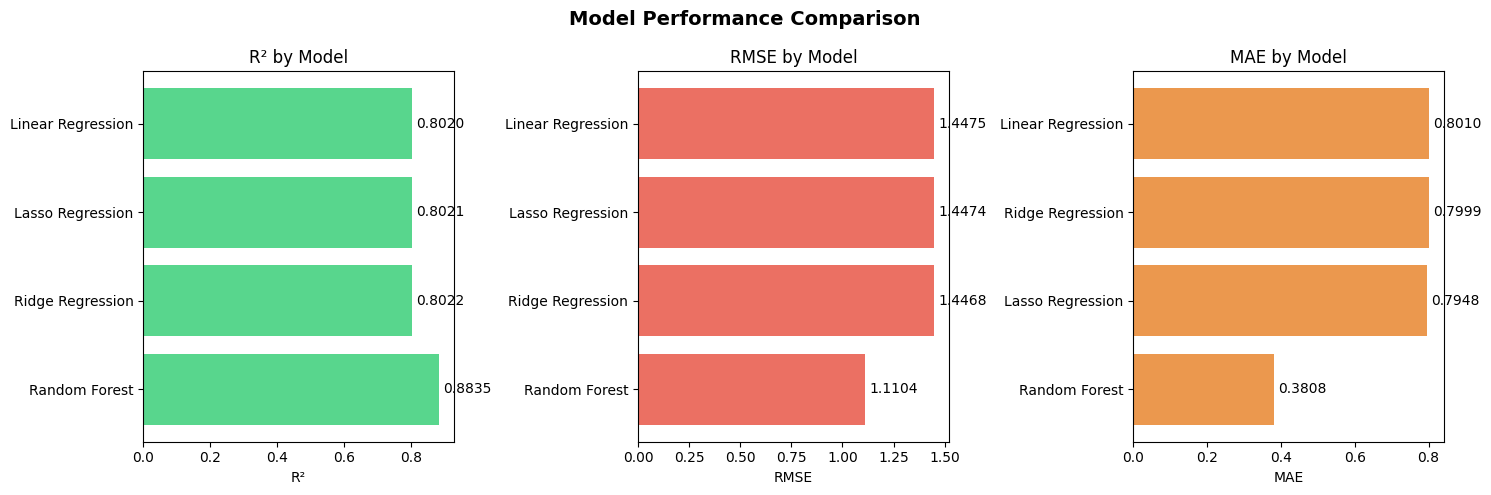

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['R²', 'RMSE', 'MAE']
colors = ['#2ecc71', '#e74c3c', '#e67e22']

for ax, metric, color in zip(axes, metrics, colors):
    sorted_df = results_df.sort_values(metric, ascending=(metric != 'R²'))
    bars = ax.barh(sorted_df['Model'], sorted_df[metric], color=color, alpha=0.8)
    ax.set_xlabel(metric)
    ax.set_title(f'{metric} by Model')
    ax.bar_label(bars, fmt='%.4f', padding=3)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()